In [1]:
import pandas as pd
import pickle

Load test data

In [2]:
x_test = pd.read_csv("../data/processed/x_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

In [3]:
x_test.head()

,SeniorCitizen,Tenure,MonthlyCharges,TotalCharges,MonthlyDataUsageGB,NumberOfComplaints,SatisfactionScore,AvgCallDuration,Gender_Male,Partner_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1.034433,1.734296,1.282218,2.694512,0.842540,-1.378470,0.191105,2.280318e-16,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.034433,-1.021849,-0.107516,-0.699439,0.911989,-1.034526,1.684877,1.482430e+00,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.034433,0.622167,-1.034829,-0.322703,-1.070686,-1.722414,-1.302668,-5.843357e-01,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,-0.966713,1.492529,0.721312,2.211642,0.000000,-1.378470,0.937991,-1.585626e+00,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1.034433,0.428754,-1.579850,-0.759557,-0.383657,0.000000,1.684877,5.517434e-01,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [4]:
x_test.shape

(11820, 34)

In [5]:
y_test.head()

0    0
1    0
2    0
3    0
4    0
Name: Churn, dtype: int64

In [6]:
y_test.shape

(11820,)

Load your trained models from the models folder.

Logistic Regression

In [7]:
with open("../models/lr_model.pkl", "rb") as file:
    lr_model = pickle.load(file)

Decision Tree

In [8]:
with open("../models/dt_model.pkl", "rb") as file:
    dt_model = pickle.load(file)

Random Forest

In [9]:
with open("../models/rf_model.pkl", "rb") as file:
    rf_model = pickle.load(file)

Gradient Boosting

In [10]:
with open("../models/gb_model.pkl", "rb") as file:
    gb_model = pickle.load(file)

Make predictions using your 4 loaded models.

In [11]:
y_pred_lr = lr_model.predict(x_test)

In [12]:
y_pred_dt = dt_model.predict(x_test)

In [13]:
y_pred_rf=rf_model.predict(x_test)

In [14]:
y_pred_gb=gb_model.predict(x_test)

Classification Report for all 4 models.

In [15]:
from sklearn.metrics import classification_report

In [16]:
print("Logistic Regression :")
print()
print(classification_report(y_test, y_pred_lr))

Logistic Regression :

              precision    recall  f1-score   support

           0       0.90      0.62      0.73     10284
           1       0.17      0.53      0.26      1536

    accuracy                           0.61     11820
   macro avg       0.54      0.57      0.50     11820
weighted avg       0.80      0.61      0.67     11820



In [17]:
print("Decision Tree :")
print()
print(classification_report(y_test, y_pred_dt))

Decision Tree :

              precision    recall  f1-score   support

           0       0.92      0.63      0.75     10284
           1       0.21      0.65      0.32      1536

    accuracy                           0.64     11820
   macro avg       0.57      0.64      0.53     11820
weighted avg       0.83      0.64      0.69     11820



In [18]:
print("Random Forest :")
print()
print(classification_report(y_test, y_pred_rf))

Random Forest :

              precision    recall  f1-score   support

           0       0.95      0.88      0.91     10284
           1       0.45      0.66      0.54      1536

    accuracy                           0.85     11820
   macro avg       0.70      0.77      0.72     11820
weighted avg       0.88      0.85      0.86     11820



In [19]:
print("Gradient Boosting :")
print()
print(classification_report(y_test, y_pred_gb))

Gradient Boosting :

              precision    recall  f1-score   support

           0       0.90      0.90      0.90     10284
           1       0.32      0.33      0.33      1536

    accuracy                           0.82     11820
   macro avg       0.61      0.61      0.61     11820
weighted avg       0.82      0.82      0.82     11820



Confusion Matrix for the models.

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [21]:
confusion_matrix(y_test,y_pred_lr)

array([[6371, 3913],
       [ 723,  813]])

In [22]:
"""
                 Predicted
                 0       1
Actual  0       TN      FP
        1       FN      TP
"""

'\n                 Predicted\n                 0       1\nActual  0       TN      FP\n        1       FN      TP\n'

In [23]:
confusion_matrix(y_test,y_pred_lr,labels=[1,0])

array([[ 813,  723],
       [3913, 6371]])

In [24]:
"""       Predicted
                 1       0
Actual  1       TP      FN
        0       FP      TN
        
"""

'       Predicted\n                 1       0\nActual  1       TP      FN\n        0       FP      TN\n\n'

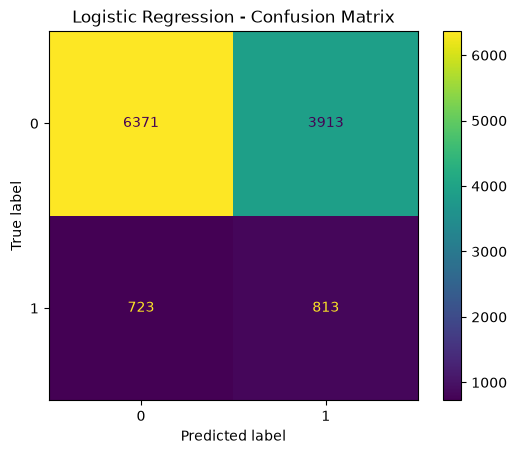

In [25]:
cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Logistic Regression - Confusion Matrix")

plt.show()

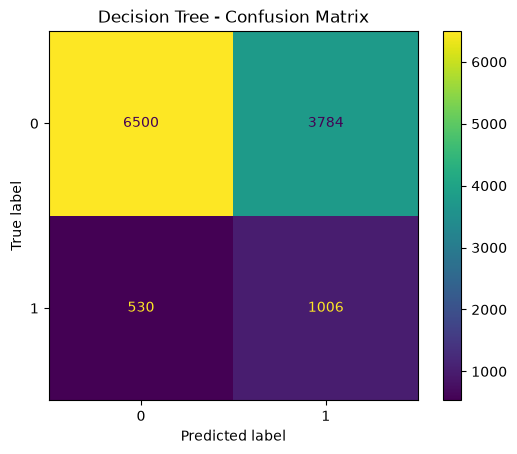

In [26]:
cm = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Decision Tree - Confusion Matrix")

plt.show()

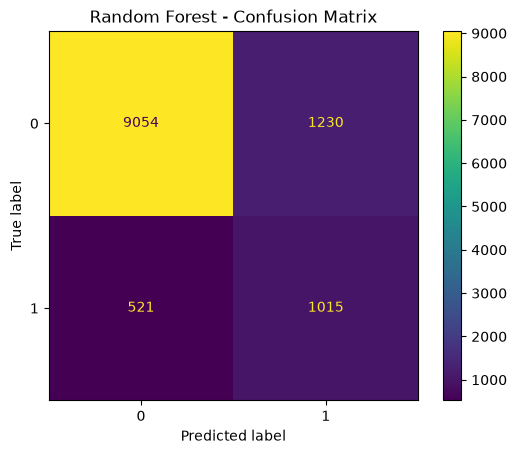

In [27]:
cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Random Forest - Confusion Matrix")

plt.show()

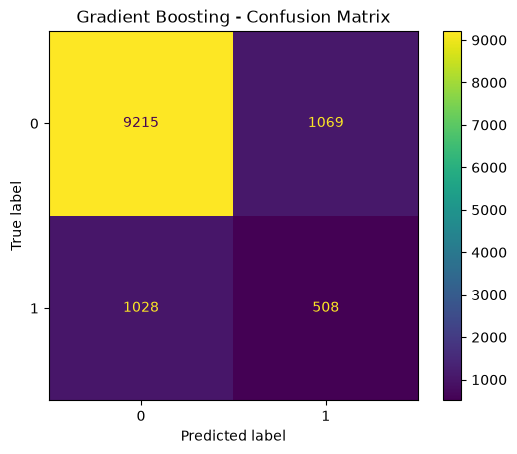

In [28]:
cm = confusion_matrix(y_test, y_pred_gb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Gradient Boosting - Confusion Matrix")

plt.show()


ROC-AUC Score for all 4 models.


In [29]:
from sklearn.metrics import roc_auc_score

In [30]:
"""
predict()       → Give me final prediction (0 or 1)

predict_proba() → Give me probability of each class

[:, 1]          → Give me probability of class 1 (Churn)

[[0.80, 0.20],
 [0.30, 0.70],
 [0.90, 0.10]]
 
 0 = No Churn
1 = Churn

Column 0 → Probability of class 0 (No Churn)
Column 1 → Probability of class 1 (Churn)

SO:
lr_model.predict_proba(x_test)[:, 1]


"""


'\npredict()       → Give me final prediction (0 or 1)\n\npredict_proba() → Give me probability of each class\n\n[:, 1]          → Give me probability of class 1 (Churn)\n\n[[0.80, 0.20],\n [0.30, 0.70],\n [0.90, 0.10]]\n\n 0 = No Churn\n1 = Churn\n\nColumn 0 → Probability of class 0 (No Churn)\nColumn 1 → Probability of class 1 (Churn)\n\nSO:\nlr_model.predict_proba(x_test)[:, 1]\n\n\n'

In [31]:


roc_lr = roc_auc_score(
    y_test,
    lr_model.predict_proba(x_test)[:, 1]
)



In [32]:
print("ROC-AUC_lr:", roc_lr)

ROC-AUC_lr: 0.6179301774905193


In [33]:
roc_dt= roc_auc_score(
    y_test,
    dt_model.predict_proba(x_test)[:, 1]
)



In [34]:
print("ROC-AUC_dt:", roc_dt)

ROC-AUC_dt: 0.6454722660301602


In [35]:
roc_rf = roc_auc_score(
    y_test,
    rf_model.predict_proba(x_test)[:, 1]
)



In [36]:
print("ROC-AUC_rf:", roc_rf)

ROC-AUC_rf: 0.8227758102189486


In [37]:
roc_gb = roc_auc_score(
    y_test,
    gb_model.predict_proba(x_test)[:, 1]
)



In [38]:
print("ROC-AUC_gb:", roc_gb)

ROC-AUC_gb: 0.6519823661654836


Compare Models

In [39]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "ROC-AUC": [
        roc_lr,
        roc_dt,
        roc_rf,
        roc_gb
    ]
})



In [40]:
results

,Model,ROC-AUC
0,Logistic Regression,0.617930
1,Decision Tree,0.645472
2,Random Forest,0.822776
3,Gradient Boosting,0.651982
